In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 6.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 68.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 62.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score 
from sklearn.feature_selection import RFE

import mlflow
import mlflow.sklearn
import os

In [4]:
import dagshub
dagshub.init(repo_owner='lchkh23', repo_name='Housing-Prices', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=40734ac9-1642-4eb1-b719-68000df1811c&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=cf02eb8454ce8d2ecf9afd9cfa5e80ec1129c86e37058af987e55c0729fe88f0




Accessing as lchkh23

Initialized MLflow to track repo "lchkh23/Housing-Prices"

Repository lchkh23/Housing-Prices initialized!

In [5]:
train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
x = train.drop(columns=["SalePrice"])
y = train["SalePrice"]

x_train, x_val, y_train, y_val = train_test_split(
    x, y, 
    test_size=0.2,
    random_state=42
)


print(f"Train size: {x_train.shape}")
print(f"Val size:  {x_val.shape}")

Train size: (1168, 80)
Val size:  (292, 80)


In [6]:
x_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1066,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal
638,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal
799,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal
380,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal


# Data Cleaning

In [7]:
missing_vals = x_train.isnull().mean() * 100
missing_vals = missing_vals.sort_values(ascending=False)
print(missing_vals)
to_drop_cols = missing_vals[missing_vals > 80].index
print(f"\nto_drop_cols below:")
print(to_drop_cols)

PoolQC           99.486301
MiscFeature      96.061644
Alley            93.664384
Fence            80.051370
MasVnrType       58.476027
                   ...    
MiscVal           0.000000
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
Length: 80, dtype: float64

to_drop_cols below:
Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence'], dtype='object')


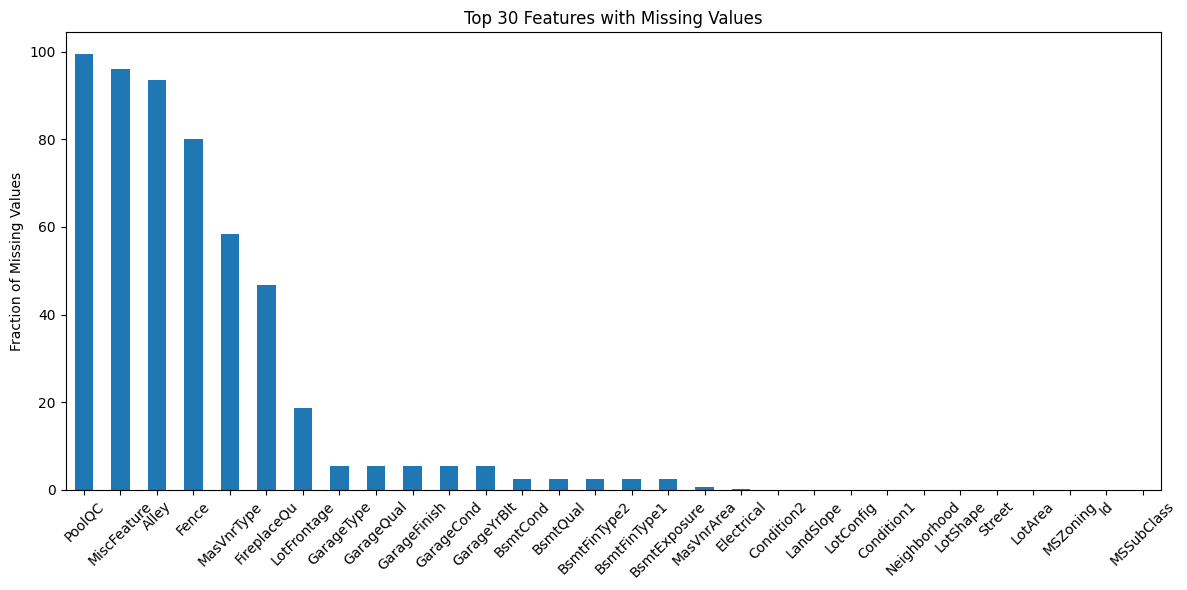

In [8]:
top_n = 30
missing_vals_sorted = missing_vals.sort_values(ascending=False).head(top_n)

plt.figure(figsize=(12,6))
missing_vals_sorted.plot(kind='bar')

plt.title(f"Top {top_n} Features with Missing Values")
plt.ylabel("Fraction of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
x_train = x_train.drop(columns=to_drop_cols)
x_val = x_val.drop(columns=to_drop_cols)

# **Substituting NaN values**

In [10]:
numeric_cols = x_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = x_train.select_dtypes(include=['object']).columns
print(numeric_cols)
print(categorical_cols)

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')
Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAi

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

def nanheatmap():
    plt.figure(figsize=(12,6))
    sns.heatmap(x_train.isnull(), cbar=False)
    plt.title("Missing Values Heatmap (Train)")
    plt.show()

BEFORE. NaN-ების განაწილების HeatMap.

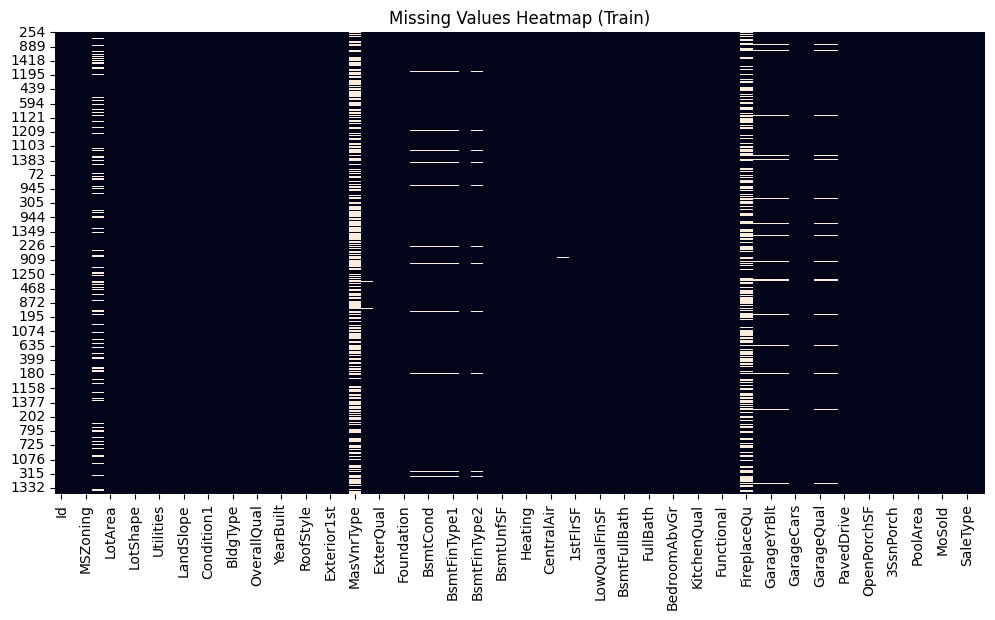

In [12]:
nanheatmap()

numeric ცვლადებს მედიანით ვანაცვლებ

In [13]:
train_medians = x_train[numeric_cols].median() 

x_train[numeric_cols] = x_train[numeric_cols].fillna(train_medians)
x_val[numeric_cols] = x_val[numeric_cols].fillna(train_medians)

categorical ცვლადებს მოდით ვანაცვლებ

In [14]:
for col in categorical_cols:
    mode_value = x_train[col].mode()[0]
    
    x_train[col] = x_train[col].fillna(mode_value)
    x_val[col] = x_val[col].fillna(mode_value)

AFTER. NaN-ების განაწილების HeatMap(მთლიანად შავი - აღარ არის NaN ცვლადები).

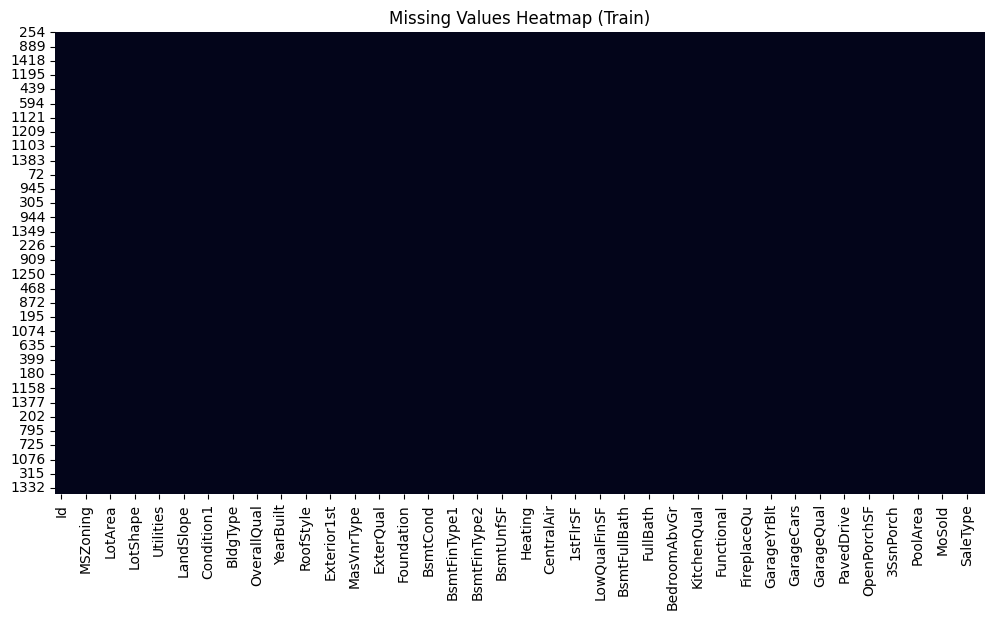

In [15]:
nanheatmap()

In [16]:
def check_distribution(df, threshold=0.90):
    results = []
    
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        dist = df[col].value_counts(normalize=True)
        dominant_pct = dist.iloc[0] * 100
        dominant_val = dist.index[0]
        results.append({'column': col, 'dominant_value': dominant_val, 
                        'dominant_pct': dominant_pct, 'type': 'categorical'})
    
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        zero_pct = (df[col] == 0).mean() * 100
        results.append({'column': col, 'dominant_value': 0, 
                        'dominant_pct': zero_pct, 'type': 'numeric(zeros)'})
    
    df_results = pd.DataFrame(results).sort_values('dominant_pct', ascending=False)
    df_results['flag'] = df_results['dominant_pct'].apply(
        lambda x: 'DROP' if x >= threshold * 100 else 'OK'
    )
    df_results['dominant_pct'] = df_results['dominant_pct'].round(2).astype(str) + '%'
    
    print(df_results.to_string(index=False))
    
    exceeded = df_results[df_results['flag'] == 'DROP']['column'].tolist()
    return exceeded

low_variance_cols = check_distribution(x_train, threshold=0.90)
print(low_variance_cols)

       column dominant_value dominant_pct           type flag
    Utilities         AllPub       99.91%    categorical DROP
       Street           Pave       99.66%    categorical DROP
     PoolArea              0       99.49% numeric(zeros) DROP
   Condition2           Norm       99.06%    categorical DROP
     RoofMatl        CompShg       98.37%    categorical DROP
    3SsnPorch              0       98.29% numeric(zeros) DROP
 LowQualFinSF              0        98.2% numeric(zeros) DROP
      Heating           GasA        97.6%    categorical DROP
   GarageCond             TA       96.32%    categorical DROP
      MiscVal              0       96.23% numeric(zeros) DROP
   GarageQual             TA       95.38%    categorical DROP
    LandSlope            Gtl       94.86%    categorical DROP
 BsmtHalfBath              0       94.35% numeric(zeros) DROP
   CentralAir              Y       92.89%    categorical DROP
   Functional            Typ       92.81%    categorical DROP
     Bsm

removing 'Utilities', 'Street', 'PoolArea', 'Condition2', 'RoofMatl', '3SsnPorch', 'LowQualFinSF', 'Heating', 'GarageCond', 'MiscVal', 'GarageQual', 'LandSlope', 'BsmtHalfBath', 'CentralAir', 'Functional', 'BsmtCond', 'Electrical', 'ScreenPorch', 'PavedDrive', 'LandContour', columns.

In [17]:
x_train = x_train.drop(columns=low_variance_cols)
x_val = x_val.drop(columns=low_variance_cols)

In [18]:
# mlflow.set_experiment("house_prices_preprocessing")

# with mlflow.start_run(run_name="preprocessing_v1"):
    
#     mlflow.log_param("high_nan_cols_dropped", str(to_drop_cols.tolist()))
#     mlflow.log_param("low_variance_threshold", 0.90)
#     mlflow.log_param("low_variance_cols_dropped", str(low_variance_cols))
    
#     mlflow.log_param("original_shape", str((1168, 80)))
#     mlflow.log_param("after_nan_drop_shape", str((1168, 76)))
#     mlflow.log_param("after_variance_drop_shape", str(x_train.shape))
    
#     mlflow.log_param("numeric_imputation", "median")
#     mlflow.log_param("categorical_imputation", "mode")

In [19]:
x_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,Condition1,BldgType,...,GarageFinish,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,MoSold,YrSold,SaleType,SaleCondition
254,255,20,RL,70.0,8400,Reg,Inside,NAmes,Norm,1Fam,...,RFn,1,294,250,0,0,6,2010,WD,Normal
1066,1067,60,RL,59.0,7837,IR1,Inside,Gilbert,Norm,1Fam,...,RFn,2,380,0,40,0,5,2009,WD,Normal
638,639,30,RL,67.0,8777,Reg,Inside,Edwards,Feedr,1Fam,...,Unf,0,0,328,0,164,5,2008,WD,Normal
799,800,50,RL,60.0,7200,Reg,Corner,SWISU,Feedr,1Fam,...,Unf,1,240,0,0,264,6,2007,WD,Normal
380,381,50,RL,50.0,5000,Reg,Inside,SWISU,Norm,1Fam,...,Unf,1,308,0,0,242,5,2010,WD,Normal


In [20]:
x_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'LotShape',
       'LotConfig', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
       'HeatingQC', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'BsmtFullBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', 'MoSold', 'YrSold', 'SaleType',
       'SaleCondition'],
      dtype='object')

In [21]:
# print(x_train.columns.tolist())
x_train['TotalSF'] = x_train['TotalBsmtSF'] + x_train['1stFlrSF'] + x_train['2ndFlrSF']
x_val['TotalSF']   = x_val['TotalBsmtSF']   + x_val['1stFlrSF']   + x_val['2ndFlrSF']
cols_to_drop = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']
x_train = x_train.drop(columns=cols_to_drop)
x_val = x_val.drop(columns=cols_to_drop)
x_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,Condition1,BldgType,...,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,MoSold,YrSold,SaleType,SaleCondition,TotalSF
254,255,20,RL,70.0,8400,Reg,Inside,NAmes,Norm,1Fam,...,1,294,250,0,0,6,2010,WD,Normal,2628
1066,1067,60,RL,59.0,7837,IR1,Inside,Gilbert,Norm,1Fam,...,2,380,0,40,0,5,2009,WD,Normal,2370
638,639,30,RL,67.0,8777,Reg,Inside,Edwards,Feedr,1Fam,...,0,0,328,0,164,5,2008,WD,Normal,1592
799,800,50,RL,60.0,7200,Reg,Corner,SWISU,Feedr,1Fam,...,1,240,0,0,264,6,2007,WD,Normal,2499
380,381,50,RL,50.0,5000,Reg,Inside,SWISU,Norm,1Fam,...,1,308,0,0,242,5,2010,WD,Normal,2717


In [22]:
x_train['TotalBath'] = x_train['FullBath'] + 0.5*x_train['HalfBath'] + x_train['BsmtFullBath']
x_val['TotalBath']   = x_val['FullBath']   + 0.5*x_val['HalfBath']   + x_val['BsmtFullBath']
x_train = x_train.drop(columns=['FullBath', 'HalfBath', 'BsmtFullBath'])
x_val   = x_val.drop(columns=['FullBath', 'HalfBath', 'BsmtFullBath'])
x_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,Condition1,BldgType,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalBath
254,255,20,RL,70.0,8400,Reg,Inside,NAmes,Norm,1Fam,...,294,250,0,0,6,2010,WD,Normal,2628,2.0
1066,1067,60,RL,59.0,7837,IR1,Inside,Gilbert,Norm,1Fam,...,380,0,40,0,5,2009,WD,Normal,2370,2.5
638,639,30,RL,67.0,8777,Reg,Inside,Edwards,Feedr,1Fam,...,0,328,0,164,5,2008,WD,Normal,1592,1.0
799,800,50,RL,60.0,7200,Reg,Corner,SWISU,Feedr,1Fam,...,240,0,0,264,6,2007,WD,Normal,2499,2.5
380,381,50,RL,50.0,5000,Reg,Inside,SWISU,Norm,1Fam,...,308,0,0,242,5,2010,WD,Normal,2717,2.0


In [23]:
x_train['HouseAge']  = x_train['YrSold'] - x_train['YearBuilt']
x_val['HouseAge']    = x_val['YrSold']   - x_val['YearBuilt']
x_train['Remodeled'] = (x_train['YearRemodAdd'] != x_train['YearBuilt']).astype(int)
x_val['Remodeled']   = (x_val['YearRemodAdd']   != x_val['YearBuilt']).astype(int)
x_train = x_train.drop(columns=['YearBuilt', 'YearRemodAdd', 'YrSold'])
x_val   = x_val.drop(columns=['YearBuilt', 'YearRemodAdd', 'YrSold'])
x_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,Condition1,BldgType,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,MoSold,SaleType,SaleCondition,TotalSF,TotalBath,HouseAge,Remodeled
254,255,20,RL,70.0,8400,Reg,Inside,NAmes,Norm,1Fam,...,250,0,0,6,WD,Normal,2628,2.0,53,0
1066,1067,60,RL,59.0,7837,IR1,Inside,Gilbert,Norm,1Fam,...,0,40,0,5,WD,Normal,2370,2.5,16,1
638,639,30,RL,67.0,8777,Reg,Inside,Edwards,Feedr,1Fam,...,328,0,164,5,WD,Normal,1592,1.0,98,1
799,800,50,RL,60.0,7200,Reg,Corner,SWISU,Feedr,1Fam,...,0,0,264,6,WD,Normal,2499,2.5,70,1
380,381,50,RL,50.0,5000,Reg,Inside,SWISU,Norm,1Fam,...,0,0,242,5,WD,Normal,2717,2.0,86,1


In [24]:
x_train['Remodeled'].value_counts()

Remodeled
0    601
1    567
Name: count, dtype: int64

In [25]:
x_train['TotalPorchSF'] = x_train['OpenPorchSF'] + x_train['WoodDeckSF'] + x_train['EnclosedPorch']
x_val['TotalPorchSF']   = x_val['OpenPorchSF']   + x_val['WoodDeckSF']   + x_val['EnclosedPorch']
x_train = x_train.drop(columns=['OpenPorchSF', 'WoodDeckSF', 'EnclosedPorch'])
x_val   = x_val.drop(columns=['OpenPorchSF', 'WoodDeckSF', 'EnclosedPorch'])
x_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,Condition1,BldgType,...,GarageCars,GarageArea,MoSold,SaleType,SaleCondition,TotalSF,TotalBath,HouseAge,Remodeled,TotalPorchSF
254,255,20,RL,70.0,8400,Reg,Inside,NAmes,Norm,1Fam,...,1,294,6,WD,Normal,2628,2.0,53,0,250
1066,1067,60,RL,59.0,7837,IR1,Inside,Gilbert,Norm,1Fam,...,2,380,5,WD,Normal,2370,2.5,16,1,40
638,639,30,RL,67.0,8777,Reg,Inside,Edwards,Feedr,1Fam,...,0,0,5,WD,Normal,1592,1.0,98,1,492
799,800,50,RL,60.0,7200,Reg,Corner,SWISU,Feedr,1Fam,...,1,240,6,WD,Normal,2499,2.5,70,1,264
380,381,50,RL,50.0,5000,Reg,Inside,SWISU,Norm,1Fam,...,1,308,5,WD,Normal,2717,2.0,86,1,242


In [26]:
xtrain_ids = x_train.pop("Id")
xval_ids = x_val.pop("Id")

In [27]:
x_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,Condition1,BldgType,HouseStyle,...,GarageCars,GarageArea,MoSold,SaleType,SaleCondition,TotalSF,TotalBath,HouseAge,Remodeled,TotalPorchSF
254,20,RL,70.0,8400,Reg,Inside,NAmes,Norm,1Fam,1Story,...,1,294,6,WD,Normal,2628,2.0,53,0,250
1066,60,RL,59.0,7837,IR1,Inside,Gilbert,Norm,1Fam,2Story,...,2,380,5,WD,Normal,2370,2.5,16,1,40
638,30,RL,67.0,8777,Reg,Inside,Edwards,Feedr,1Fam,1Story,...,0,0,5,WD,Normal,1592,1.0,98,1,492
799,50,RL,60.0,7200,Reg,Corner,SWISU,Feedr,1Fam,1.5Fin,...,1,240,6,WD,Normal,2499,2.5,70,1,264
380,50,RL,50.0,5000,Reg,Inside,SWISU,Norm,1Fam,1.5Fin,...,1,308,5,WD,Normal,2717,2.0,86,1,242


In [28]:
x_train.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'LotShape',
       'LotConfig', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'RoofStyle', 'Exterior1st', 'Exterior2nd',
       'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'HeatingQC', 'GrLivArea',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'MoSold', 'SaleType',
       'SaleCondition', 'TotalSF', 'TotalBath', 'HouseAge', 'Remodeled',
       'TotalPorchSF'],
      dtype='object')

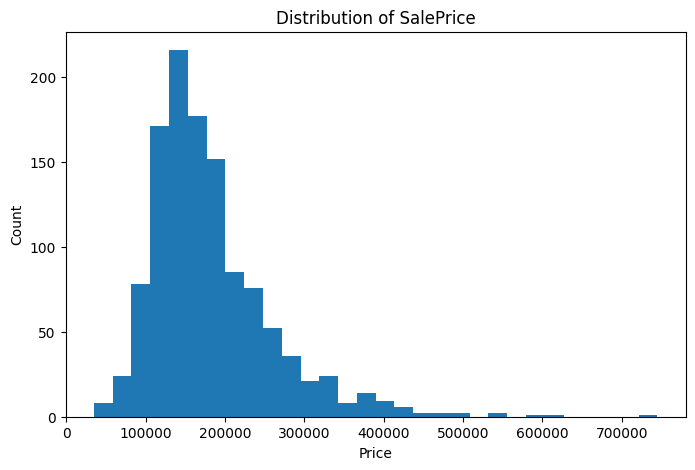

In [29]:
import matplotlib.pyplot as plt
def priceDistr():
    plt.figure(figsize=(8,5))
    plt.hist(y_train, bins=30)

    plt.title("Distribution of SalePrice")
    plt.xlabel("Price")
    plt.ylabel("Count")

    plt.show()
priceDistr()

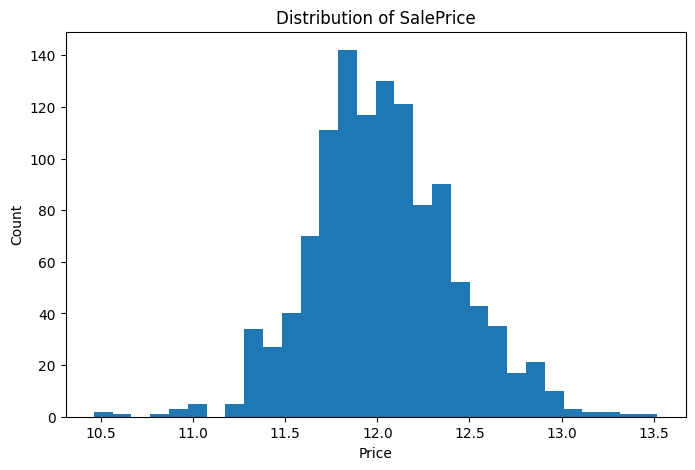

In [30]:
y_train = np.log1p(y_train)
y_val   = np.log1p(y_val)
priceDistr()

ordinal encoding

In [31]:
quality_map = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 
             'HeatingQC', 'KitchenQual', 'FireplaceQu']

for col in qual_cols:
    x_train[col] = x_train[col].map(quality_map)
    x_val[col]   = x_val[col].map(quality_map)

In [32]:
exposure_map = {'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
x_train['BsmtExposure'] = x_train['BsmtExposure'].map(exposure_map)
x_val['BsmtExposure']   = x_val['BsmtExposure'].map(exposure_map)

In [33]:
bsmt_map = {'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
x_train['BsmtFinType1'] = x_train['BsmtFinType1'].map(bsmt_map)
x_val['BsmtFinType1']   = x_val['BsmtFinType1'].map(bsmt_map)
x_train['BsmtFinType2'] = x_train['BsmtFinType2'].map(bsmt_map)
x_val['BsmtFinType2']   = x_val['BsmtFinType2'].map(bsmt_map)

In [34]:
garage_map = {'Unf': 1, 'RFn': 2, 'Fin': 3}
x_train['GarageFinish'] = x_train['GarageFinish'].map(garage_map)
x_val['GarageFinish']   = x_val['GarageFinish'].map(garage_map)

In [35]:
temp = x_train[['Neighborhood']].copy()
temp['SalePrice'] = y_train.values
neighborhood_means = temp.groupby('Neighborhood')['SalePrice'].mean()

x_train['Neighborhood'] = x_train['Neighborhood'].map(neighborhood_means)
x_val['Neighborhood']   = x_val['Neighborhood'].map(neighborhood_means)

left categorical columns for ohe

In [36]:
print(x_train.select_dtypes(include=['object']).columns.tolist())

['MSZoning', 'LotShape', 'LotConfig', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'GarageType', 'SaleType', 'SaleCondition']


ohe

In [37]:
cat_cols = x_train.select_dtypes(include=['object']).columns.tolist()

x_train = pd.get_dummies(x_train, columns=cat_cols, drop_first=True)
x_val   = pd.get_dummies(x_val,   columns=cat_cols, drop_first=True)

x_train, x_val = x_train.align(x_val, join='left', axis=1, fill_value=0)

print(x_train.shape)
print(x_val.shape)

(1168, 123)
(292, 123)


In [38]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled   = scaler.transform(x_val)

In [40]:
estimator = LinearRegression()
rfe = RFE(estimator, n_features_to_select=40)
rfe.fit(x_train_scaled, y_train)

x_train_rfe = rfe.transform(x_train_scaled)
x_val_rfe   = rfe.transform(x_val_scaled)

selected_cols = x_train.columns[rfe.support_].tolist()
print(f"Selected {len(selected_cols)} features:")
print(selected_cols)

Selected 40 features:
['LotFrontage', 'LotArea', 'Neighborhood', 'OverallQual', 'OverallCond', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'HeatingQC', 'GrLivArea', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'TotalSF', 'TotalBath', 'HouseAge', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'LotShape_IR3', 'LotConfig_CulDSac', 'Condition1_Norm', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'HouseStyle_1Story', 'HouseStyle_2Story', 'RoofStyle_Gable', 'RoofStyle_Hip', 'Exterior1st_BrkFace', 'Foundation_CBlock', 'Foundation_PConc', 'SaleCondition_Normal', 'SaleCondition_Partial']


In [41]:
x_train_rfe_df = pd.DataFrame(x_train_rfe, columns=selected_cols)
x_val_rfe_df   = pd.DataFrame(x_val_rfe,   columns=selected_cols)

corr_matrix = x_train_rfe_df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.85)]
print("Dropping due to high correlation:", to_drop_corr)

x_train_final = x_train_rfe_df.drop(columns=to_drop_corr)
x_val_final   = x_val_rfe_df.drop(columns=to_drop_corr)

print(f"Final shape: {x_train_final.shape}")

Dropping due to high correlation: ['TotalSF', 'RoofStyle_Hip']
Final shape: (1168, 38)


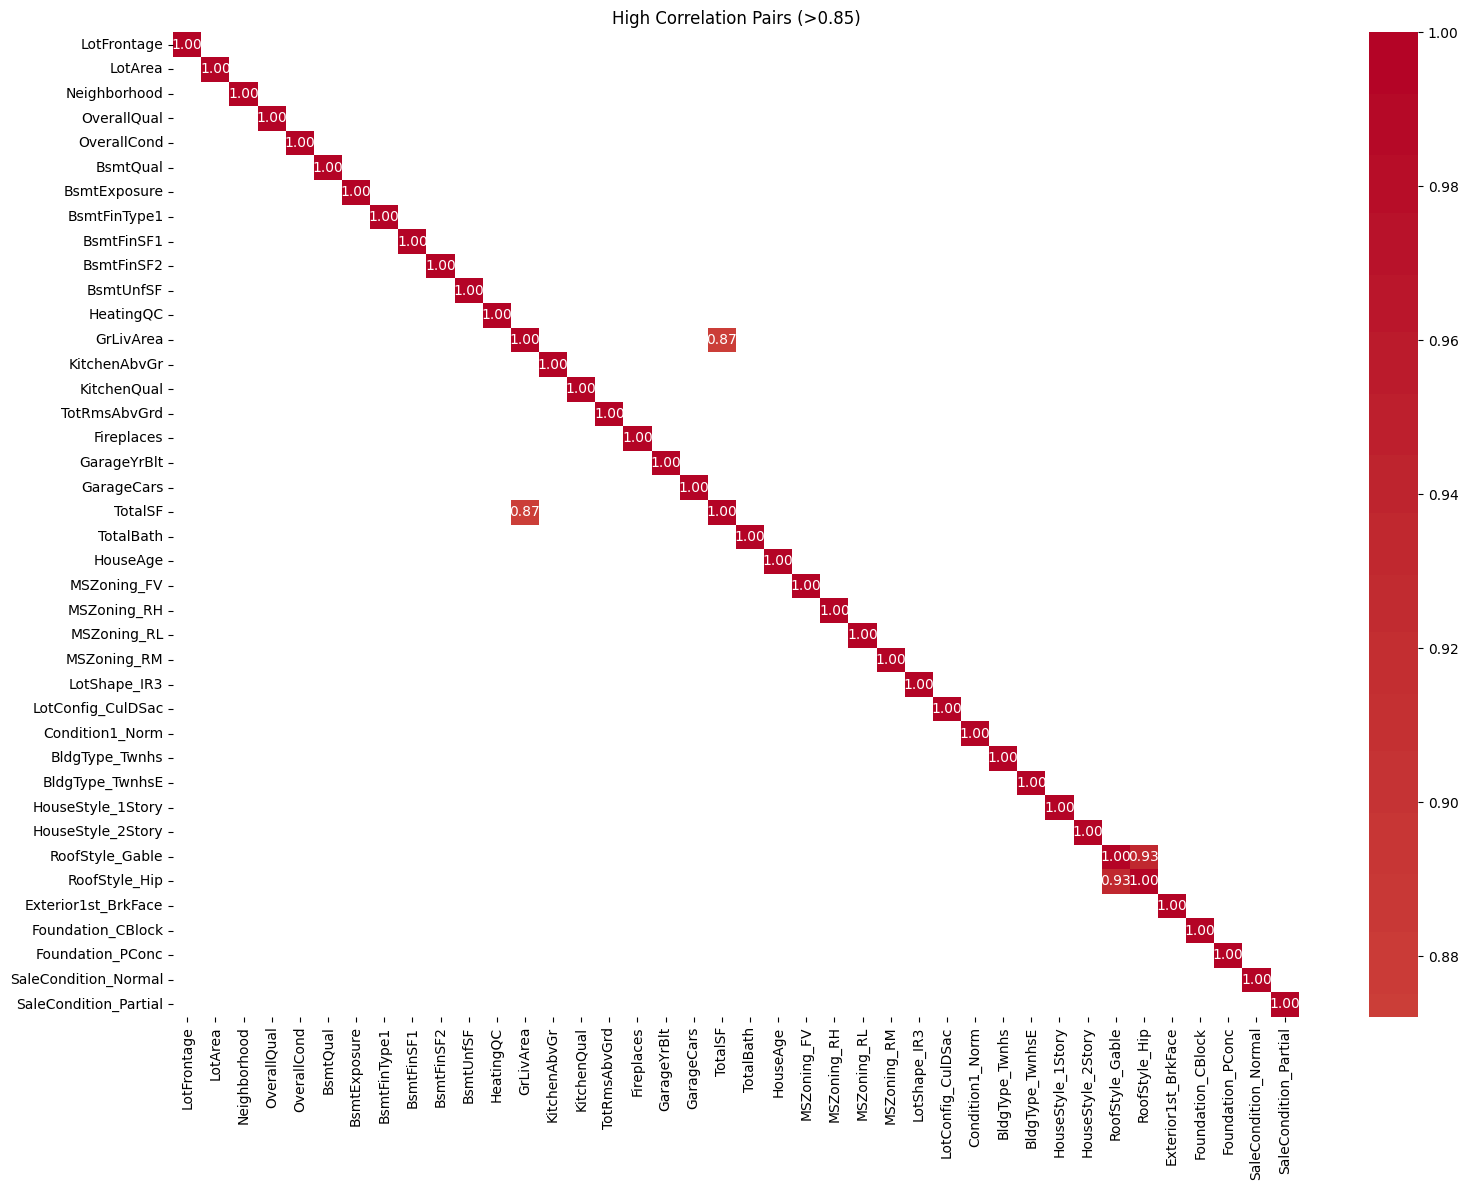

In [42]:
high_corr = corr_matrix[corr_matrix.abs() > 0.85]

plt.figure(figsize=(16, 12))
sns.heatmap(high_corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)

plt.title("High Correlation Pairs (>0.85)")
plt.tight_layout()
plt.show()

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import mlflow

In [44]:
# LINEAR
with mlflow.start_run(run_name="linear_best"):
    # preprocessing
    mlflow.log_param("nan_threshold", 0.80)
    mlflow.log_param("variance_threshold", 0.90)
    mlflow.log_param("numeric_imputation", "median")
    mlflow.log_param("categorical_imputation", "mode")
    mlflow.log_param("features_created", "TotalSF, TotalBath, HouseAge, Remodeled, TotalPorchSF")
    mlflow.log_param("rfe_features", 40)
    mlflow.log_param("correlation_threshold", 0.85)
    mlflow.log_param("final_features", x_train_final.shape[1])
    
    # model
    mlflow.log_param("model", "LinearRegression")
    
    # train
    model = LinearRegression()
    model.fit(x_train_final, y_train)
    
    train_preds = model.predict(x_train_final)
    val_preds   = model.predict(x_val_final)
    
    train_rmsle = np.sqrt(mean_squared_error(y_train, train_preds))
    val_rmsle   = np.sqrt(mean_squared_error(y_val, val_preds))
    
    print(f"Train RMSLE: {train_rmsle:.4f}")
    print(f"Val RMSLE:   {val_rmsle:.4f}")
    
    mlflow.log_metric("train_rmsle", train_rmsle)
    mlflow.log_metric("val_rmsle", val_rmsle)
    
    # save model and scaler
    mlflow.sklearn.log_model(model, "model")
    mlflow.sklearn.log_model(scaler, "scaler")
    
    print(f"Run ID: {mlflow.active_run().info.run_id}")

Train RMSLE: 0.1275
Val RMSLE:   0.1294


2026/04/12 10:54:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 10:54:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/12 10:55:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 10:55:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Run ID: b04579db90b841e58346739060beb73d
🏃 View run linear_best at: https://dagshub.com/lchkh23/Housing-Prices.mlflow/#/experiments/0/runs/b04579db90b841e58346739060beb73d
🧪 View experiment at: https://dagshub.com/lchkh23/Housing-Prices.mlflow/#/experiments/0


In [45]:
# # RIDGE
# from sklearn.linear_model import Ridge

# alpha = 0.01
# with mlflow.start_run(run_name=f"Ridge_alpha{alpha}"):
#     mlflow.log_param("nan_threshold", 0.80)
#     mlflow.log_param("variance_threshold", 0.90)
#     mlflow.log_param("numeric_imputation", "median")
#     mlflow.log_param("categorical_imputation", "mode")
#     mlflow.log_param("features_created", "TotalSF, TotalBath, HouseAge, Remodeled, TotalPorchSF")
#     mlflow.log_param("rfe_features", 40)
#     mlflow.log_param("correlation_threshold", 0.85)
#     mlflow.log_param("final_features", x_train_final.shape[1])
    
#     mlflow.log_param("model", "Ridge")
#     mlflow.log_param("alpha", alpha)
        
#     model = Ridge(alpha=alpha)
#     model.fit(x_train_final, y_train)
        
#     train_preds = model.predict(x_train_final)
#     val_preds   = model.predict(x_val_final)
        
#     train_rmsle = np.sqrt(mean_squared_error(y_train, train_preds))
#     val_rmsle   = np.sqrt(mean_squared_error(y_val, val_preds))
        
#     print(f"Alpha {alpha} → Train: {train_rmsle:.4f} | Val: {val_rmsle:.4f}")
        
#     mlflow.log_metric("train_rmsle", train_rmsle)
#     mlflow.log_metric("val_rmsle", val_rmsle)

In [46]:
# # XGBOOST
# from xgboost import XGBRegressor
# with mlflow.start_run(run_name="XGBoost_v1"):
#     mlflow.log_param("nan_threshold", 0.80)
#     mlflow.log_param("variance_threshold", 0.90)
#     mlflow.log_param("numeric_imputation", "median")
#     mlflow.log_param("categorical_imputation", "mode")
#     mlflow.log_param("features_created", "TotalSF, TotalBath, HouseAge, Remodeled, TotalPorchSF")
#     mlflow.log_param("rfe_features", 40)
#     mlflow.log_param("correlation_threshold", 0.85)
#     mlflow.log_param("final_features", x_train_final.shape[1])
#     mlflow.log_param("model", "XGBoost")
#     mlflow.log_param("max_depth", 3)
#     mlflow.log_param("learning_rate", 0.05)
#     mlflow.log_param("n_estimators", 200)
#     mlflow.log_param("subsample", 0.8)
#     mlflow.log_param("colsample_bytree", 0.8)
    
#     model = XGBRegressor(
#         n_estimators=200,
#         max_depth=3,
#         learning_rate=0.05,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         random_state=42
#     )
#     model.fit(x_train_final, y_train)
    
#     train_preds = model.predict(x_train_final)
#     val_preds   = model.predict(x_val_final)
    
#     train_rmsle = np.sqrt(mean_squared_error(y_train, train_preds))
#     val_rmsle   = np.sqrt(mean_squared_error(y_val, val_preds))
    
#     print(f"XGBoost → Train: {train_rmsle:.4f} | Val: {val_rmsle:.4f}")
    
#     mlflow.log_metric("train_rmsle", train_rmsle)
#     mlflow.log_metric("val_rmsle", val_rmsle)

In [47]:
# # LASSO
# from sklearn.linear_model import Lasso

# for alpha in [0.0001, 0.001, 0.01, 0.1]:
#     with mlflow.start_run(run_name=f"lasso_alpha{alpha}"):
#         mlflow.log_param("nan_threshold", 0.80)
#         mlflow.log_param("variance_threshold", 0.90)
#         mlflow.log_param("numeric_imputation", "median")
#         mlflow.log_param("categorical_imputation", "mode")
#         mlflow.log_param("features_created", "TotalSF, TotalBath, HouseAge, Remodeled, TotalPorchSF")
#         mlflow.log_param("rfe_features", 40)
#         mlflow.log_param("correlation_threshold", 0.85)
#         mlflow.log_param("final_features", x_train_final.shape[1])
#         model = Lasso(alpha=alpha, random_state=42)
#         model.fit(x_train_final, y_train)
        
#         train_preds = model.predict(x_train_final)
#         val_preds   = model.predict(x_val_final)
        
#         train_rmsle = np.sqrt(mean_squared_error(y_train, train_preds))
#         val_rmsle   = np.sqrt(mean_squared_error(y_val, val_preds))
        
#         n_features_kept = sum(model.coef_ != 0)
        
#         print(f"alpha={alpha} → Train: {train_rmsle:.4f} | Val: {val_rmsle:.4f} | Features kept: {n_features_kept}")
        
#         mlflow.log_param("model", "Lasso")
#         mlflow.log_param("alpha", alpha)
#         mlflow.log_metric("train_rmsle", train_rmsle)
#         mlflow.log_metric("val_rmsle", val_rmsle)
#         mlflow.log_metric("features_kept", n_features_kept)

In [48]:
# # RANDOM FOREST
# from sklearn.ensemble import RandomForestRegressor

# for n_estimators, max_depth in [
#     (100, None),
#     (200, 15),
# ]:
#     with mlflow.start_run(run_name=f"RF_n{n_estimators}_depth{max_depth}"):
#         mlflow.log_param("nan_threshold", 0.80)
#         mlflow.log_param("variance_threshold", 0.90)
#         mlflow.log_param("numeric_imputation", "median")
#         mlflow.log_param("categorical_imputation", "mode")
#         mlflow.log_param("features_created", "TotalSF, TotalBath, HouseAge, Remodeled, TotalPorchSF")
#         mlflow.log_param("rfe_features", 60)
#         mlflow.log_param("correlation_threshold", 0.85)
#         model = RandomForestRegressor(
#             n_estimators=n_estimators,
#             max_depth=max_depth,
#             random_state=42
#         )
#         model.fit(x_train_final, y_train)
        
#         train_preds = model.predict(x_train_final)
#         val_preds   = model.predict(x_val_final)
        
#         train_rmsle = np.sqrt(mean_squared_error(y_train, train_preds))
#         val_rmsle   = np.sqrt(mean_squared_error(y_val, val_preds))
        
#         print(f"n={n_estimators} depth={max_depth} → Train: {train_rmsle:.4f} | Val: {val_rmsle:.4f}")
        
#         mlflow.log_param("model", "RandomForest")
#         mlflow.log_param("n_estimators", n_estimators)
#         mlflow.log_param("max_depth", max_depth)
#         mlflow.log_metric("train_rmsle", train_rmsle)
#         mlflow.log_metric("val_rmsle", val_rmsle)